In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

from   iminuit import Minuit                    # type: ignore
from   iminuit.cost import LeastSquares         # type: ignore
from   matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt                 # type: ignore
import numpy as np  
import pandas as pd                             # type: ignore
import pickle
from   PIL import Image                         # type: ignore
import scipy
from   scipy.optimize import curve_fit

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

In [2]:
# Main directories and files
KR_H5 = '/lhome/ific/c/ccortesp/Analysis/temp/h5/energy_scale_lowbg_fullrun.h5'
OUTPUT_PAPER = '/lhome/ific/c/ccortesp/Papers/RnLPRPaper/fig/'

# Load dataframe
KR_DF = pd.read_hdf(KR_H5)
KR_DF

,time,e0,e0u,elt,eltu,run,ts
0,1.753147e+09,8252.197461,0.149931,31.471374,0.589599,15609,2025-07-22 03:23:44.556530
1,1.753244e+09,8253.163180,0.227370,31.351767,0.562935,15614,2025-07-23 06:16:04.995733
2,1.753328e+09,8249.267515,0.218222,34.606192,0.661172,15615,2025-07-24 05:35:10.046992
3,1.753414e+09,8252.333704,0.223355,33.222847,0.586962,15616,2025-07-25 05:19:43.844530
4,1.753502e+09,8271.984477,0.200530,33.216925,0.680802,15617,2025-07-26 05:45:26.006479
...,...,...,...,...,...,...,...
62,1.758939e+09,8225.667036,0.150743,32.328149,0.478259,15733,2025-09-27 04:17:05.048126
63,1.759026e+09,8236.656797,0.125764,33.568633,0.527629,15734,2025-09-28 04:15:57.620727
64,1.759112e+09,8239.187861,0.122069,33.482072,0.501514,15735,2025-09-29 04:15:27.553136
65,1.759203e+09,8237.806970,0.135477,33.964985,0.513820,15736,2025-09-30 05:32:37.118072


# Plot

In [4]:
# Extracting data
Date     = np.array(KR_DF['time'])
Lifetime = np.array(KR_DF['elt'])
Lifetime_err = np.array(KR_DF['eltu'])

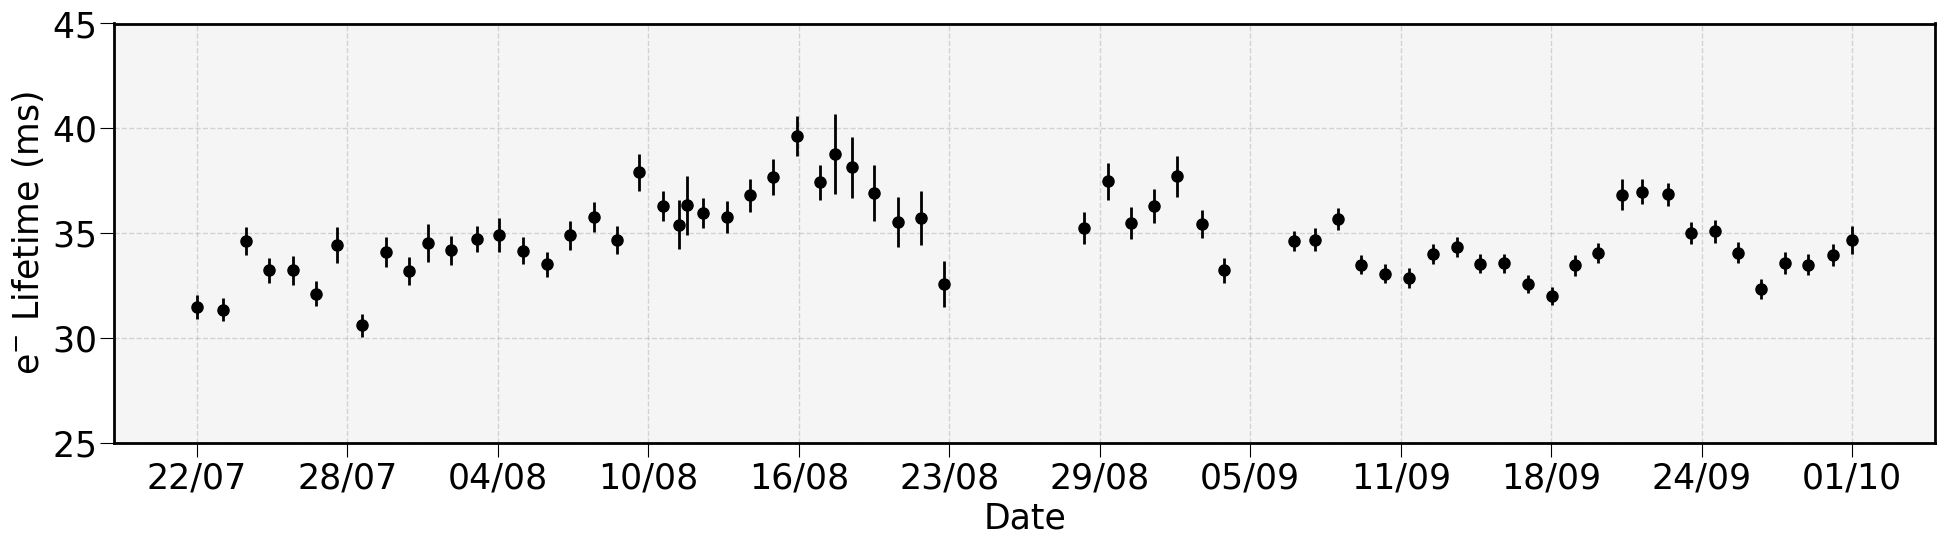

In [14]:
# ----- Plotting ---- #
fig, ax = plt.subplots(figsize=(20, 6))

# Data
plt.errorbar(Date, Lifetime, yerr=Lifetime_err, fmt='o', c='black', ecolor='black')

# ---- Styling ---- #
x_labels  = [crudo.epoch_converter(t, h=False) for t in Date]        # Convert x-axis bin edges to readable time format
num_ticks = 12                                                       # Number of ticks to display
uniform_dates = np.linspace(Date.min(), Date.max(), num_ticks)       # Uniformly spaced dates
uniform_labels = [crudo.epoch_converter(t, h=False) for t in uniform_dates]  # Convert to readable format

plt.xlabel('Date')
plt.xticks(uniform_dates, uniform_labels, rotation=0, ha='center')
plt.ylabel(r'e$^{-}$ Lifetime (ms)')
plt.ylim(25, 45)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
plt.savefig(OUTPUT_PAPER + 'LowBG_Lifetime.pdf')
plt.show()